In [1]:
import os
gpu_activate = True
if gpu_activate:
    os.environ["DEVITO_LANGUAGE"] = "cuda"
    os.environ["DEVITO_ARCH"]     = "nvcc"
    os.environ["DEVITO_PLATFORM"] = "nvidiaX"  
from devito import configuration
configuration['log-level'] = 'ERROR'
print(configuration)
###############################
from devito import *
from devitopro import *
from examples.seismic import plot_velocity, RickerSource, TimeAxis, Receiver
from devitocurvilinear import SeismicModel
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from sympy import init_printing, latex
import time
init_printing(use_latex='mathjax')

# Some ploting setup
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('xtick', labelsize=12) 
plt.rc('ytick', labelsize=12)
fonttitle=14
fontlabel=12
savefig=True

Parameters({'platform': TargetPlatform[nvidiaX], 'compiler': JITCompiler[CudaCompiler], 'language': 'cuda', 'mpi': False, 'topology': None, 'first-touch': False, 'ignore-unknowns': False, 'log-level': 'ERROR', 'jit-backdoor': False, 'safe-math': False, 'autopadding': False, 'deviceid': -1, 'autotuning': (False, 'preemptive'), 'develop-mode': False, 'opt': 'advanced', 'opt-options': {}, 'profiling': 'basic'})


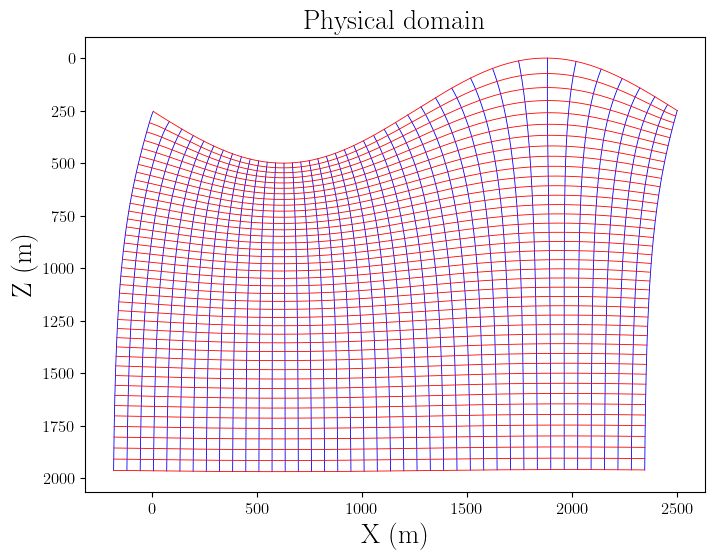

In [2]:

#######################################
from devitocurvilinear import meshgrid_from_topo

L = 2500.0       # period (m)
H = 1650.0        # depth extent for eta (m)
S = L/(2*np.pi)

def y_s(x):
    """Periodic topography y(x) over [0,L)."""
    x = np.asarray(x, dtype=float)
    #base = (100*np.sin(2*np.pi*x/L) + 0.08*np.exp(-((x - 0.75*L)/(0.12*L))**2))*2.5
    base = 250*np.sin(2*np.pi*x/L)+250
    return base
n_xi = 801
n_eta = 801
x_top = np.linspace(0.0, L, num=n_xi)
y_top = y_s(x_top)

X, Z = meshgrid_from_topo(x_top, y_top, n_xi=n_xi, n_eta=n_eta, H=H, max_iter=10,beta=1.0)
fig, ax = plt.subplots()
skip = 20
# --- Physical domain ---
for i in range(0, X.shape[1], skip):
    ax.plot(X[:, i], Z[:, i], linewidth=0.6, color='blue')
for j in range(0, X.shape[0], skip):
    ax.plot(X[j, :], Z[j, :], linewidth=0.6, color='red')
ax.set_xlabel('X (m)', fontsize=20)
ax.set_ylabel('Z (m)', fontsize=20)
ax.set_title('Physical domain', fontsize=20)
ax.invert_yaxis()
ax.set_aspect('equal')
plt.show()

In [3]:
from devitocurvilinear import CurviMap
eta = np.linspace(0.0, 1.0, num=n_eta)
xi = np.linspace(0.0, 1.0, num=n_xi)
Xi, Eta = np.meshgrid(xi, eta) 
cm = CurviMap(Xi, Eta, X, Z)
from scipy.interpolate import  interp1d
top = interp1d(X[0,:],Z[0,:], kind='linear', fill_value='extrapolate')


In [4]:
if 1:
    np.savetxt('top.dat', np.column_stack((x_top.flatten(), 2000-top(x_top).flatten())), fmt='%f')

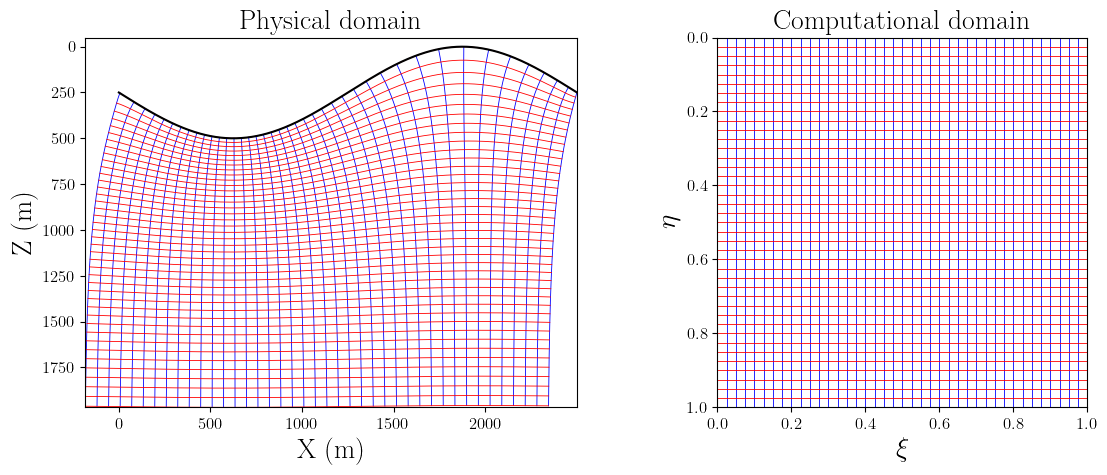

In [5]:

###################################
allplots = False
#if allplots:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# --- Physical domain ---
for i in range(0, X.shape[1], skip):
    axes[0].plot(X[:, i], Z[:, i], linewidth=0.6, color='blue')
for j in range(0, X.shape[0], skip):
    axes[0].plot(X[j, :], Z[j, :], linewidth=0.6, color='red')
axes[0].set_xlabel('X (m)', fontsize=20)
axes[0].set_ylabel('Z (m)', fontsize=20)
axes[0].set_title('Physical domain', fontsize=20)
axes[0].set_xlim(X.min(), X.max())
axes[0].set_ylim(Z.max(), Z.min()-50)
axes[0].set_aspect('equal')
axes[0].plot(x_top, y_top, 'k', label='Smoothed')
# --- Computational domain ---
for i in range(0, Xi.shape[1], skip):
    axes[1].plot(Xi[:, i], Eta[:, i], linewidth=0.6, color='blue')
for j in range(0, Xi.shape[0], skip):
    axes[1].plot(Xi[j, :], Eta[j, :], linewidth=0.6, color='red')
axes[1].set_xlabel(r'$\xi$', fontsize=20)
axes[1].set_ylabel(r'$\eta$', fontsize=20)
axes[1].set_title('Computational domain', fontsize=20)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(1, 0)
axes[1].set_aspect('equal')
plt.tight_layout()
plt.show()
if savefig:
    fig.savefig('mesh_homo.pdf', transparent=True,bbox_inches='tight')
    fig.savefig('mesh_homo.png', transparent=True,bbox_inches='tight')

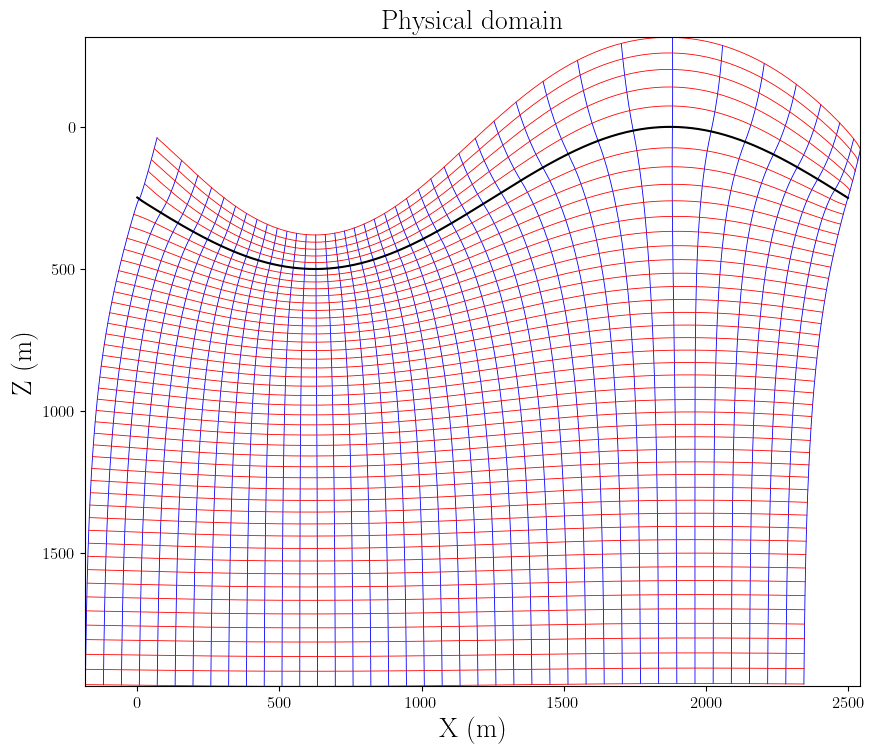

In [6]:
# Mirror samples in borders of X and Z
Xmirror = np.vstack([2*X[0,:]-X[100:0:-1, :], X])
Zmirror = np.vstack([2*Z[0,:]-Z[100:0:-1, :], Z])
# hstack
# Xmirror = np.hstack([2*Xmirror[:,0:1]-Xmirror[:,100:0:-1], Xmirror, 2*Xmirror[:,-1:]-Xmirror[:,-1:-100:-1]])
# Zmirror = np.hstack([2*Zmirror[:,0:1]-Zmirror[:,100:0:-1], Zmirror, 2*Zmirror[:,-1:]-Zmirror[:,-1:-100:-1]])


fig, axes = plt.subplots(1, 1, figsize=(10, 10))
# --- Physical domain ---
for i in range(0, Xmirror.shape[1], skip):
    axes.plot(Xmirror[:, i], Zmirror[:, i], linewidth=0.6, color='blue')
for j in range(0, Xmirror.shape[0], skip):
    axes.plot(Xmirror[j, :], Zmirror[j, :], linewidth=0.6, color='red')
axes.set_xlabel('X (m)', fontsize=20)
axes.set_ylabel('Z (m)', fontsize=20)
axes.set_title('Physical domain', fontsize=20)
axes.set_xlim(Xmirror.min(), Xmirror.max())
axes.set_ylim(Zmirror.max(), Zmirror.min())
axes.set_aspect('equal')
axes.plot(x_top, top(x_top), 'k', label='Smoothed')

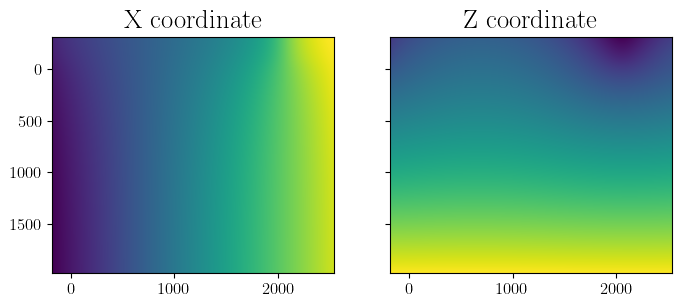

In [7]:
fig, ax = plt.subplots(1,2 , sharey=True)
ax[0].imshow(Xmirror, extent=[Xmirror.min(), Xmirror.max(), Zmirror.max(), Zmirror.min()], aspect='equal')
ax[0].set_title('X coordinate')
ax[1].imshow(Zmirror, extent=[Xmirror.min(), Xmirror.max(), Zmirror.max(), Zmirror.min()], aspect='equal')
ax[1].set_title('Z coordinate')
plt.show()

dsxi: min=0.573814 max=7.003180
dseta: min=0.737976 max=4.330308


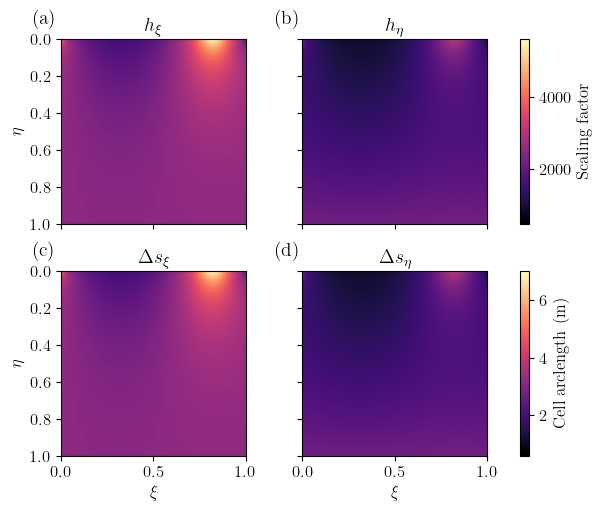

In [8]:
#######################################
from devitocurvilinear import deriv1_8th
deta = eta[1]-eta[0]
dxi  = xi[1]-xi[0]
# x_eta, x_xi = np.gradient(Xmirror, deta, dxi, edge_order=2)   # shape (ny, nx)
# z_eta, z_xi = np.gradient(Zmirror, deta, dxi, edge_order=2)   # shape (ny, nx)

# x_eta = x_eta[200:,:]
# z_eta = z_eta[200:,:]
#X, Z have shape (ny, nx) with axes: eta (0), xi (1)


# x_eta = deriv1_8th(Xmirror, deta, axis=0)
# x_eta = x_eta[100:,:]
x_eta = deriv1_8th(X, deta, axis=0)
x_xi  = deriv1_8th(X, dxi,  axis=1)


# z_eta = deriv1_8th(Zmirror, deta, axis=0)
# z_eta = z_eta[100:,:]
z_eta = deriv1_8th(Z, deta, axis=0)
z_xi  = deriv1_8th(Z, dxi,  axis=1)
#x_xi * x_eta + z_xi * z_eta
#z_xi = -x_xi * x_eta  / z_eta 

a_xi = (x_xi, z_xi)/np.sqrt(x_xi**2+z_xi**2)
a_eta = (x_eta, z_eta)/np.sqrt(x_eta**2+z_eta**2)
h_xi = np.sqrt(x_xi**2 + z_xi**2)
h_eta = np.sqrt(x_eta**2 + z_eta**2)

hmap = 'magma'
hmin, hmax = min(h_xi.min(), h_eta.min()), max(h_xi.max(), h_eta.max())
fig, axes = plt.subplots(2, 2,  sharey=True, sharex=True, figsize=(6,5), layout='constrained')
ax=axes[0,0]
im0 = ax.imshow(h_xi, cmap=hmap,extent=[xi.min(), xi.max(), eta.max(), eta.min()], vmin=hmin, vmax=hmax)
ax.set_title(r'$h_\xi$', fontsize=fonttitle)
ax.set_ylabel(r'$\eta$', fontsize=fontlabel)
#cb=fig.colorbar(im0, ax=ax[0], label='(m)',orientation='horizontal')
#cb.ax.tick_params(labelsize=14)
ax=axes[0,1]
im1 = ax.imshow(h_eta, cmap=hmap,extent=[xi.min(), xi.max(), eta.max(), eta.min()], vmin=hmin, vmax=hmax)
ax.set_title(r'$h_\eta$', fontsize=fonttitle)
cb=fig.colorbar(im1, ax=axes[0,:], orientation='vertical')
cb.set_label('Scaling factor', fontsize=fontlabel)
cb.ax.tick_params(labelsize=fontlabel)
dsxi = h_xi*dxi
dseta = h_eta*deta
# Print maximum and minimum values of dsxi and dseta
print(f"dsxi: min={dsxi.min():.6f} max={dsxi.max():.6f}")
print(f"dseta: min={dseta.min():.6f} max={dseta.max():.6f}")
hmap = 'magma'
dmin, dmax = min(dsxi.min(), dseta.min()), max(dsxi.max(), dseta.max())
ax=axes[1,0]
im0 = ax.imshow(dsxi, cmap=hmap,extent=[xi.min(), xi.max(), eta.max(), eta.min()], vmin=dmin, vmax=dmax)
ax.set_title(r'$\Delta s_\xi$', fontsize=fonttitle)
ax.set_ylabel(r'$\eta$', fontsize=fontlabel)
ax.set_xlabel(r'$\xi$', fontsize=fontlabel)

ax=axes[1,1]
im1 = ax.imshow(dseta, cmap=hmap,extent=[xi.min(), xi.max(), eta.max(), eta.min()], vmin=dmin, vmax=dmax)
ax.set_title(r'$\Delta s_\eta$', fontsize=fonttitle)
ax.set_xlabel(r'$\xi$', fontsize=fontlabel)
cb=fig.colorbar(im1, ax=axes[1,:],orientation='vertical')
cb.set_label('Cell arclength (m)', fontsize=fontlabel)
cb.ax.tick_params(labelsize=fontlabel)

axes[0,0].text(-0.15, 1.08, '(a)', fontsize=14, transform=axes[0,0].transAxes)
axes[0,1].text(-0.15, 1.08, '(b)', fontsize=14, transform=axes[0,1].transAxes)
axes[1,0].text(-0.15, 1.08, '(c)', fontsize=14, transform=axes[1,0].transAxes)
axes[1,1].text(-0.15, 1.08, '(d)', fontsize=14, transform=axes[1,1].transAxes)

plt.show()
if savefig:
    fig.savefig('scale_factors.pdf', transparent=True,bbox_inches='tight')
    fig.savefig('scale_factors.png', transparent=True,bbox_inches='tight')

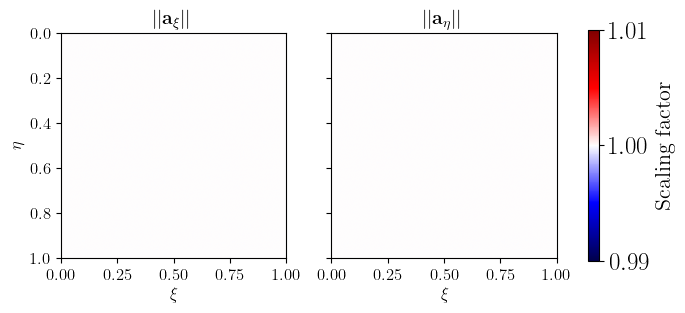

In [9]:
fig, ax = plt.subplots(1, 2,  sharey=True)
normaxi = np.sqrt(a_xi[0]**2+a_xi[1]**2)
normaeta = np.sqrt(a_eta[0]**2+a_eta[1]**2)
im0 = ax[0].imshow(normaxi, cmap='seismic',extent=[xi.min(), xi.max(), eta.max(), eta.min()], vmin=0.99, vmax=1.01)
ax[0].set_title(r'$||\mathbf{a}_\xi||$', fontsize=fonttitle)
ax[0].set_ylabel(r'$\eta$', fontsize=fontlabel)
ax[0].set_xlabel(r'$\xi$', fontsize=fontlabel)
#cb=fig.colorbar(im0, ax=ax[0], label='(m)',orientation='horizontal')
#cb.ax.tick_params(labelsize=14)
im1 = ax[1].imshow(normaeta, cmap='seismic',extent=[xi.min(), xi.max(), eta.max(), eta.min()], vmin=0.99, vmax=1.01)
ax[1].set_title(r'$||\mathbf{a}_\eta||$', fontsize=fonttitle)
ax[1].set_xlabel(r'$\xi$', fontsize=fontlabel)
cb=fig.colorbar(im1, ax=ax, label='Scaling factor',orientation='vertical',shrink=0.5)
cb.ax.tick_params(labelsize=18)
plt.show()

Minimim Jacobian value: 270011.22371669643
Maximum orthogonality value: 0.4458843505323674


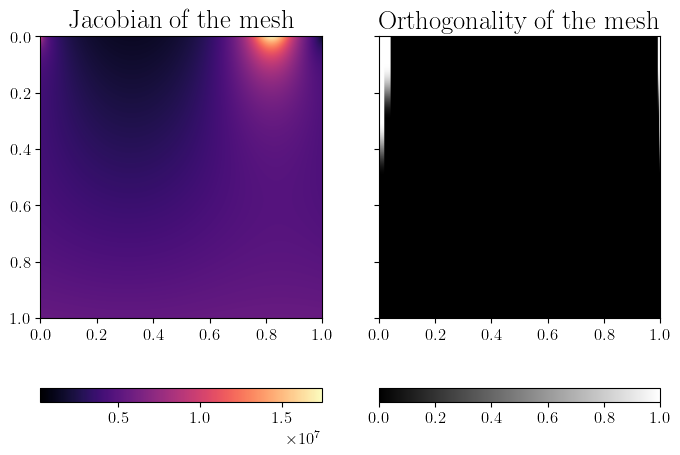

In [10]:
# Mesh orthogonality check
J = x_xi * z_eta - x_eta * z_xi
#O = (x_xi * x_eta + z_xi * z_eta) / (np.sqrt(x_xi**2 + z_xi**2) * np.sqrt(x_eta**2 + z_eta**2))
O = a_xi[0]*a_eta[0] + a_xi[1]*a_eta[1]
print("Minimim Jacobian value:", np.min(J))
print("Maximum orthogonality value:", np.max(O))
fig, ax = plt.subplots(1, 2,  sharey=True)
im1 = ax[0].imshow(J, cmap='magma', extent=[xi.min(), xi.max(), eta.max(), eta.min()])
fig.colorbar(im1, ax=ax[0], orientation='horizontal')
ax[0].set_title("Jacobian of the mesh")
#im2 = ax[1].imshow(O, cmap='seismic', extent=[xi.min(), xi.max(), eta.max(), eta.min()], vmin=-1e-4, vmax=1e-4)
im2 = ax[1].imshow(np.abs(O[:5,:])>1e-3, cmap='gray', extent=[xi.min(), xi.max(), eta.max(), eta.min()], vmin=0, vmax=1)
fig.colorbar(im2, ax=ax[1], orientation='horizontal')
ax[1].set_title("Orthogonality of the mesh")
plt.show()

Time step dt = 0.14 ms
1100.00 351.98
(array([0.59530892]), array([0.00650319]))
Number of time steps: 10758


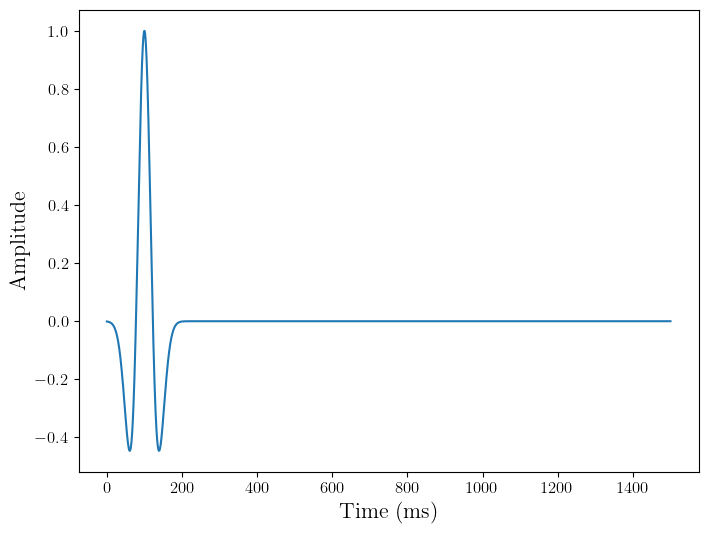

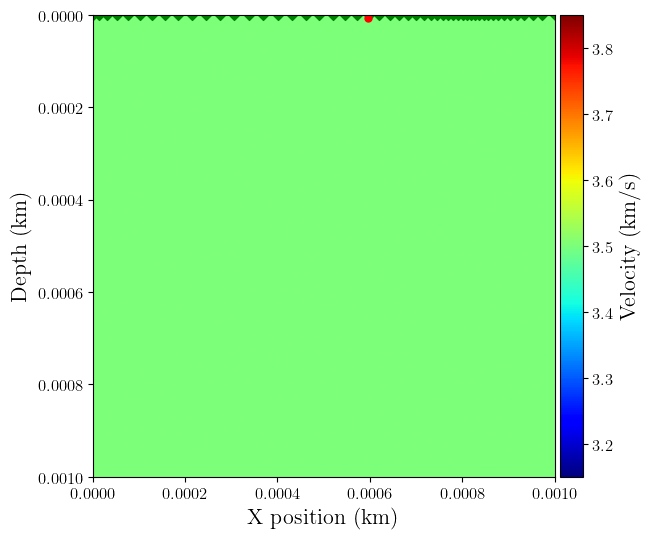

In [11]:
shape = Xi.T.shape # Number of grid point (nx, nz)
spacing = (dxi, deta)  # Grid spacing in m. 
origin = (0., 0.)  # What is the location of the top left corner. This is necessary to define
so= 8
nbl=50
vp = 2.5 * np.ones(shape, dtype=np.float32)  # Velocity in km/s
vs = 1.5 * np.ones(shape, dtype=np.float32)  # Shear velocity in km/s
b = 0.5 * np.ones(shape, dtype=np.float32)
# With the velocity and model size defined, we can create the seismic model that
# encapsulates this properties. We also define the size of the absorbing layer as 10 grid points
vmax = vp.max()
#W = np.array([9/8,-1/24])
W = np.array([1225/1024, -245/3072, 49/5120, -5/7168])
dt = 0.99/((np.sqrt(np.max((1/(dxi*h_xi))**2 + (1/(deta*h_eta))**2)))*vmax*np.sum(np.abs(W))) 
#dt = 0.9/((np.sqrt((1/(dxi*h_xi.min()))**2 + (1/(deta*h_eta.min()))**2))*vmax*np.sum(np.abs(W))) 
print(f"Time step dt = {dt:.2f} ms")
model = SeismicModel(vp=vp, vs=vs, b=b, dt=dt, hxi=h_xi.T, heta=h_eta.T, 
                     origin=origin, shape=shape, spacing=spacing, space_order=so, nbl=nbl,fs=True, bcs='damp')

###########################################
t0 = 0.  # Simulation starts a t=0
tn = 1500.  # Simulation last 1 second (1000 ms)
time_range = TimeAxis(start=t0, stop=tn, step=dt)

f0 = 0.010  # Source peak frequency is 10Hz (0.010 kHz)
src = RickerSource(name='src', grid=model.grid, f0=f0, time_range=time_range)
shotposx= 1100.  # Source position in m
shotposz= 10. + top(shotposx) # Depth is 10m
print(f"{shotposx:.2f} {shotposz:.2f}")
coordinates = cm.p2c(np.array([shotposx]), np.array([shotposz]))
print(coordinates)
print("Number of time steps:", time_range.num)
src.coordinates.data[:] = np.vstack((coordinates[0], coordinates[1])).T
src.show()

############################################
s = model.grid.time_dim.spacing
v = VectorTimeFunction(name='v', grid=model.grid, space_order=so, time_order=1)
tau = TensorTimeFunction(name='tau', grid=model.grid, space_order=so, time_order=1)

src_xx = src.inject(field=tau.forward[0, 0], expr=s*src)
src_zz = src.inject(field=tau.forward[1, 1], expr=s*src)

# Receivers
#rec_coordsx = np.linspace(X[0, 0], X[0, -2], num=401)
rec_coordsx = np.linspace(0, 2500, num=201)
rec_coordsz = (1e-4)*np.ones(rec_coordsx.shape) +top(rec_coordsx) # Depth is 10m
rec_coords = np.vstack(cm.p2c(rec_coordsx, rec_coordsz)).T
recvx = Receiver(name="recvx", grid=model.grid, time_range=time_range, coordinates=rec_coords)
recvz = Receiver(name="recvz", grid=model.grid, time_range=time_range, coordinates=rec_coords) 
rec_term = recvx.interpolate(expr=v[0])
rec_term += recvz.interpolate(expr=v[1])

plot_velocity(model, source=src.coordinates.data, receiver=recvx.coordinates.data[::4, :])

In [12]:

############################################
x, y = model.grid.dimensions
k=1
class Main(SubDomain):
    name = 'main'
    def define(self, dimensions):
        x, y = dimensions
        return {
            x: x,                    # full width; or ('middle', nbl, nbl) to drop side PML
            y: ('middle', k, 0)      # exclude k rows at top, 0 at bottom
        }

class FreeSurface(SubDomain):
    name = 'freesurface'
    def define(self, dimensions):
        x, y = dimensions
        return {
            x: x,                    # full width; or ('middle', nbl, nbl)
            y: ('left', k)           # first k rows only (top band)
        }

main = Main(grid=model.grid)
freesurface = FreeSurface(grid=model.grid)

##############################################################################
# Lame parameters
l, mu, ro = model.lam, model.mu, model.b
# Scaling factors for curvilinear coordinates
hxi, heta = model.hxi, model.heta
# Mirror scale factors in the ABC region
# hxi.data[:nbl,:] = hxi.data[nbl:2*nbl,:][::-1,:]
# hxi.data[-nbl:,:] = hxi.data[-2*nbl:-nbl,:][::-1,:]
# heta.data[:nbl,:] = heta.data[nbl:2*nbl,:][::-1,:]
# heta.data[-nbl:,:] = heta.data[-2*nbl:-nbl,:][::-1,:]

# Now let's try and create the staggered updates
model.damp.data[:] = np.exp(-(1e-3)*model.damp.data)
 
# The velocity and stress equations
# The velocity and stress equations
# div_corr_x = (0.5*(tau[0,1] + tau[0,1].shift(y,-1))  * hxi.dy - 0.5*(tau[1,1] + tau[1,1].forward.shift(x,1)) * heta.dx) / (hxi*heta)
# div_corr_z = (0.5*(tau[0,1] + tau[0,1].shift(x,-1))  * heta.dx - 0.5*(tau[0,0] + tau[0,0].forward.shift(y,1)) * hxi.dy) / (hxi*heta)

div_corr_x = (tau[0,1] * hxi.dy - tau[1,1] * heta.dx) / (hxi*heta)
div_corr_z = (tau[0,1] * heta.dx - tau[0,0] * hxi.dy) / (hxi*heta)

u_vx = Eq(v[0].forward,
          model.damp * solve(v[0].dt
                             - ro*(1/(hxi*heta))*((heta*tau[0,0]).dx + (hxi*tau[0,1]).dy)
                             - ro*div_corr_x,
                             v[0].forward),
          subdomain=model.grid)

u_vz = Eq(v[1].forward,
          model.damp * solve(v[1].dt
                             - ro*(1/(hxi*heta))*((heta*tau[0,1]).dx + (hxi*tau[1,1]).dy)
                             - ro*div_corr_z,
                             v[1].forward),
          subdomain=model.grid)

# u_vx = Eq(v[0].forward, model.damp * solve(v[0].dt - ro*(1/(hxi*heta))*( (heta*tau[0,0]).dx  + (hxi*tau[0,1]).dy ), 
#                                            v[0].forward), subdomain=model.grid)
# u_vz = Eq(v[1].forward, model.damp * solve(v[1].dt - ro*(1/(hxi*heta))*( (heta*tau[0,1]).dx  +  (hxi*tau[1,1]).dy ), 
#                                            v[1].forward), subdomain=model.grid)
# vz_c = 0.5*(v[1].forward + v[1].forward.shift(y,-1))
# vx_c = 0.5*(v[0].forward + v[0].forward.shift(x,-1))
# vx_s = 0.5*(v[0].forward + v[0].forward.shift(y,1))
# vz_s = 0.5*(v[1].forward + v[1].forward.shift(x,1))

vz_c = v[1].forward 
vx_c = v[0].forward 
vx_s = v[0].forward 
vz_s = v[1].forward 


u_txx = Eq(tau[0,0].forward, model.damp * solve(
    tau[0,0].dt - (
        (l+2*mu)*((1/hxi)*v[0].forward.dx +
                  (1/(hxi*heta))* (vz_c) * hxi.dy) +
        l*((1/heta)*v[1].forward.dy +
           (1/(hxi*heta))* (vx_c) * heta.dx)
    ),
    tau[0,0].forward),
    subdomain=main)

u_tzz = Eq(tau[1,1].forward, model.damp * solve(
    tau[1,1].dt - (
        l*((1/hxi)*v[0].forward.dx +
           (1/(hxi*heta))* (vz_c) * hxi.dy) +
        (l+2*mu)*((1/heta)*v[1].forward.dy +
                  (1/(hxi*heta))* (vx_c) * heta.dx)
    ),
    tau[1,1].forward),
    subdomain=main)

u_txz = Eq(tau[0,1].forward, model.damp * solve(
    tau[0,1].dt - mu*(
        (1/heta)*v[0].forward.dy +
        (1/hxi)*v[1].forward.dx -
        (1/(hxi*heta))* (vx_s) * hxi.dy -
        (1/(hxi*heta))* (vz_s) * heta.dx
    ),
    tau[0,1].forward),
    subdomain=model.grid)


u_v = [u_vx, u_vz]
u_tau = [u_txx, u_txz, u_tzz]


# Free surface condition
bc_tzz = Eq(tau[1,1].forward, 0, subdomain=freesurface)
bc_txx = Eq(tau[0,0].forward, model.damp * solve(tau[0,0].dt - ((4*mu*(l+mu))/(l+2*mu))* ((1/hxi)*v[0].forward.dx + 
                                                              (1/(hxi*heta))*vz_c * hxi.dy), 
                                                 tau[0,0].forward), subdomain=freesurface)

# Stress image method
bc_tzz1 = Eq(tau[1,1].forward.subs({y: y-1}), -tau[1,1].forward.subs({y: y+1}), subdomain=freesurface)
bc_tzz2 = Eq(tau[1,1].forward.subs({y: y-2}), -tau[1,1].forward.subs({y: y+2}), subdomain=freesurface)
bc_tzz3 = Eq(tau[1,1].forward.subs({y: y-3}), -tau[1,1].forward.subs({y: y+3}), subdomain=freesurface)
bc_txz1 = Eq(tau[0,1].forward.subs({y: y-1}), -tau[0,1].forward, subdomain=freesurface)
bc_txz2 = Eq(tau[0,1].forward.subs({y: y-2}), -tau[0,1].forward.subs({y: y+1}), subdomain=freesurface)
bc_txz3 = Eq(tau[0,1].forward.subs({y: y-3}), -tau[0,1].forward.subs({y: y+2}), subdomain=freesurface)
bc_txz4 = Eq(tau[0,1].forward.subs({y: y-4}), -tau[0,1].forward.subs({y: y+3}), subdomain=freesurface)

eqns = u_v  + u_tau + [bc_txx] + [bc_tzz, bc_tzz1, bc_tzz2, bc_tzz3] + [bc_txz1, bc_txz2, bc_txz3, bc_txz4] + src_xx + src_zz + rec_term
op = Operator(eqns)
#############################
snap = int(0.4/(dt*1e-3))
start_time = time.perf_counter()
op(dt=dt, time_M=snap)
end_time = time.perf_counter()
elapsed_time1 = end_time - start_time

In [13]:
print(op.ccode)

/* NON-COMMERCIAL, NON-EXCLUSIVE, NON-TRANSFERABLE SOFTWARE LICENSE

Copyright (c) 2021-25, Devito Codes Ltd, Riverside House,
1-5 Como Street, Romford, Essex, RM7 7DN, United Kingdom.

Definitions:

* "Devito Codes": Refers to Devito Codes Ltd., a company incorporated and operating under the laws of England and Wales, and encompasses all its divisions, affiliates, and subsidiaries involved in the development and licensing of software products.
* "Software": Includes all software products developed by Devito Codes, such as Devito PRO, and any other software titles offered by Devito Codes, along with their associated materials, documentation, and software generated by their respective compilers or runtime environments.
* "Licensee": Denotes any individual, company, or entity that has legally acquired a copy or license of the Software under the terms specified in an Agreement with Devito Codes. This term also encompasses all employees, contractors, and agents acting within the scope of t

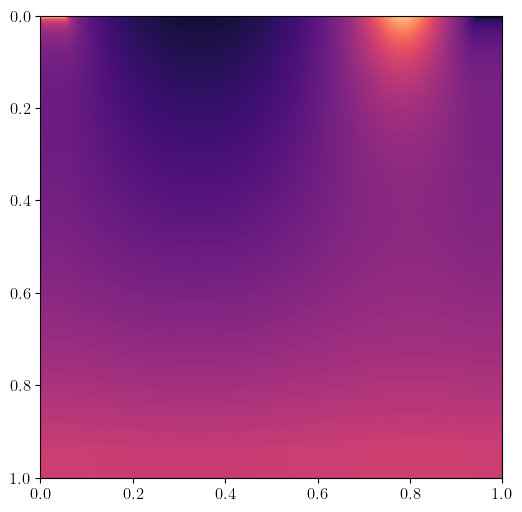

In [14]:
plt.imshow(heta.data.T, extent=[0, 1, 1, 0], cmap='magma')

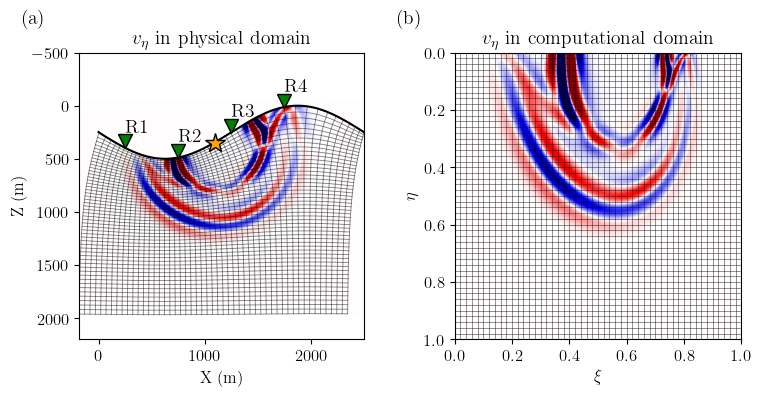

In [15]:
scale=np.max(np.abs(v[1].data[0][model.nbl:-model.nbl, model.nbl:-model.nbl]))*0.3
slices = [slice(model.nbl, -model.nbl), slice(0, -model.nbl)]
vz_comp = v[1].data[0][slices].T

xn,zn = np.linspace(X.min(), X.max(), 1000), np.linspace(Z.min()-50, Z.max(), 1000)
Xn,Zn = np.meshgrid(xn, zn)
from scipy.interpolate import griddata
v_phy = griddata(points=(X.ravel(), Z.ravel()),values=vz_comp.ravel(),xi=(Xn, Zn),method='linear',fill_value=0.0)
mask = Zn > top(Xn)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
skip = 16

# --- Left subplot: computational domain image (vz_comp) ---
ax = axes[1]
im0 = ax.imshow(
    vz_comp, cmap='seismic', vmin=-scale, vmax=scale,
    extent=[Xi.min(), Xi.max(), Eta.max(), Eta.min()]
)
for i in range(0, Xi.shape[1], skip):
    ax.plot(Xi[:, i], Eta[:, i], color='k', linestyle='-', alpha=0.5, linewidth=0.6)
for j in range(0, Xi.shape[0], skip):
    ax.plot(Xi[j, :], Eta[j, :], color='k', linestyle='-', alpha=0.5, linewidth=0.6)
ax.set_aspect('equal', adjustable='box')
ax.set_title("$v_\\eta$ in computational domain", fontsize=14)
ax.set_xlabel(r'$\xi$', fontsize=12)
ax.set_ylabel(r'$\eta$', fontsize=12)


# --- Right subplot: physical domain image (v_phy*mask) ---
ax = axes[0]
im1 = ax.imshow(
    v_phy * mask, cmap='seismic', vmin=-scale, vmax=scale,
    extent=[Xn.min(), Xn.max(), Zn.max(), Zn.min()]
)
ax.plot(x_top, top(x_top), color='black')
for i in range(0, X.shape[1], skip):
    ax.plot(X[:, i], Z[:, i], color='k', linestyle='-', alpha=0.5, linewidth=0.6)
for j in range(0, X.shape[0], skip):
    ax.plot(X[j, :], Z[j, :], color='k', linestyle='-', alpha=0.5, linewidth=0.6)
ax.set_aspect('equal', adjustable='box')
ax.set_title("$v_\\eta$ in physical domain", fontsize=14)
ax.set_xlabel('X (m)', fontsize=12)
ax.set_ylabel('Z (m)', fontsize=12)
ax.set_xlim(Xn.min(), Xn.max())
ax.set_ylim(2200, -500)
ax.plot(shotposx, shotposz, marker='*', linestyle='none', markersize=15, c='orange', markeredgewidth=1, markeredgecolor='k')
traces = [20,60,100,140]
ax.plot(rec_coordsx[traces], rec_coordsz[traces]-60, marker='v', linestyle='none', markersize=10, c='green', markeredgewidth=1, markeredgecolor='k')
ax.text(rec_coordsx[traces[0]], rec_coordsz[traces[0]]-150, 'R1', fontsize=14)
ax.text(rec_coordsx[traces[1]], rec_coordsz[traces[1]]-150, 'R2', fontsize=14)
ax.text(rec_coordsx[traces[2]], rec_coordsz[traces[2]]-150, 'R3', fontsize=14)
ax.text(rec_coordsx[traces[3]], rec_coordsz[traces[3]]-150, 'R4', fontsize=14)

axes[0].text(-0.2, 1.1, '(a)', fontsize=14, transform=axes[0].transAxes)
axes[1].text(-0.2, 1.1, '(b)', fontsize=14, transform=axes[1].transAxes)


plt.tight_layout()
plt.show()
savefig= True
if savefig:
    fig.savefig('wave_homotop.pdf', transparent=True,bbox_inches='tight')
    fig.savefig('wave_homotop.png', transparent=True,bbox_inches='tight')


In [16]:
traces = [20,60,100,140]
rec_coordsx[traces]

array([ 250.,  750., 1250., 1750.])

In [17]:
#############################
start_time = time.perf_counter()
op(dt=dt, time_m=snap)
end_time = time.perf_counter()
elapsed_time = end_time - start_time + elapsed_time1
print("Execution time:", elapsed_time )

Execution time: 4.959883609903045


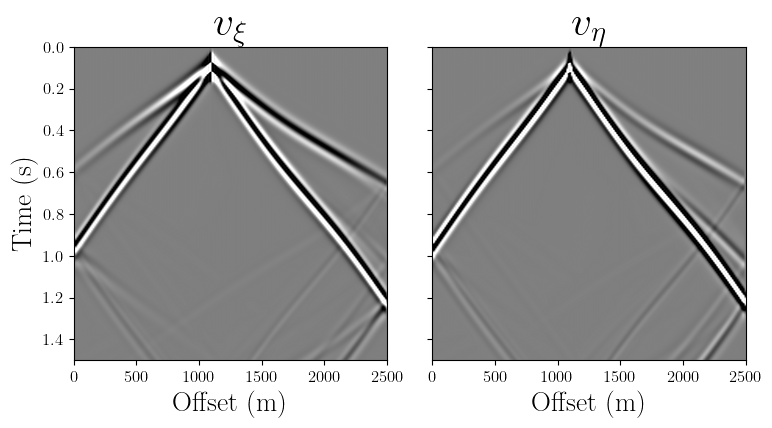

In [18]:
scale = 1e-3
#extent = [rec_coordsx[0]-shotposx, rec_coordsx[-1]-shotposx, 1e-3*tn, t0]
extent = [rec_coordsx[0], rec_coordsx[-1], 1e-3*tn, t0]
aspect = (rec_coordsx.max()-rec_coordsx.min())/(1e-3*tn)
v_xi = recvx.data
v_eta = recvz.data
fig, axes = plt.subplots(1, 2, sharey=True)
# Left: v_xi
im0 = axes[0].imshow(v_xi, vmin=-scale, vmax=scale, cmap="gray",
                     interpolation='lanczos', extent=extent, aspect=aspect)
axes[0].set_ylabel("Time (s)", fontsize=20)
axes[0].set_xlabel("Offset (m)", fontsize=20)
axes[0].set_title(r"$v_\xi$", fontsize=30)
# Right: v_eta
im1 = axes[1].imshow(v_eta, vmin=-scale, vmax=scale, cmap="gray",
                     interpolation='lanczos', extent=extent, aspect=aspect)
axes[1].set_xlabel("Offset (m)", fontsize=20)
axes[1].set_title(r"$v_\eta$", fontsize=30)

plt.tight_layout()
plt.show()

if savefig:
    fig.savefig('data_curvilinear_homo.pdf', transparent=True,bbox_inches='tight')
    fig.savefig('data_curvilinear_homo.png', transparent=True,bbox_inches='tight')


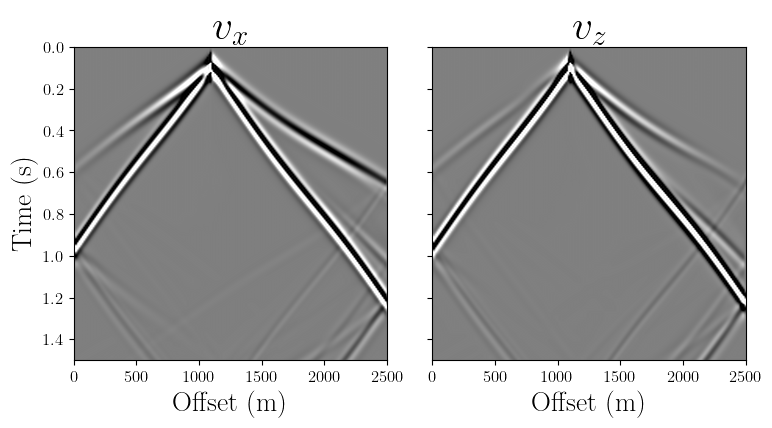

In [19]:
##########################################
vx, vz = cm.vel_c2p(v_xi, v_eta, rec_coordsx, rec_coordsz)
fig, axes = plt.subplots(1, 2, sharey=True)
# Left: v_x
axes[0].imshow(vx, vmin=-scale, vmax=scale, cmap="gray",
               interpolation='lanczos', extent=extent, aspect=aspect)
axes[0].set_ylabel("Time (s)", fontsize=20)
axes[0].set_xlabel("Offset (m)", fontsize=20)
axes[0].set_title(r"$v_x$", fontsize=30)
# Right: v_z
axes[1].imshow(vz, vmin=-scale, vmax=scale, cmap="gray",
               interpolation='lanczos', extent=extent, aspect=aspect)
axes[1].set_xlabel("Offset (m)", fontsize=20)
axes[1].set_title(r"$v_z$", fontsize=30)
plt.tight_layout()
plt.show()

if savefig:
    fig.savefig('data_cartesian_homo.pdf', transparent=True,bbox_inches='tight')
    fig.savefig('data_cartesian_homo.png', transparent=True,bbox_inches='tight')

In [20]:
# save data to file
np.savez('data_devito_homotop.npz', vx=vx, vz=vz, vxi=v_xi, veta=v_eta, dt=dt, posx=rec_coordsx)

In [21]:
2000-(top(1100)+10)

np.float64(1648.0159053501513)

In [22]:
if 1:
    np.savetxt('../../specfem2d_examples/homotop/top.dat', np.column_stack((x_top.flatten(), 2000 - y_top.flatten())), fmt='%f')

In [24]:
2000-top(500)

np.float64(1512.238823196885)

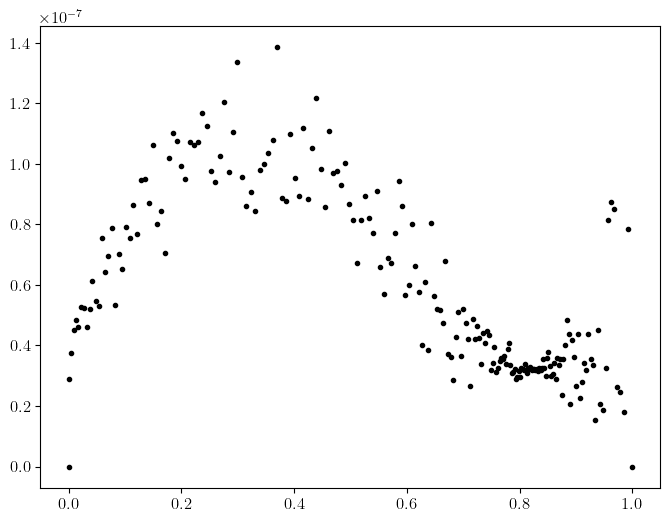

In [25]:
plt.plot(rec_coords[:,0], rec_coords[:,1], 'k.')